# FoodHub Data Analysis


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

==============================================================================

Foodhubis a company that has an app that provides access to multiple restaurants in the city of NewYork where customers can place orders for food at any restaurant and have it delivered to them by delivery people from FoodHub. Their delivery people pick up delveries from a restaurant after an order has been made on the app by a customer and confirmed by a restaurant. The delivery people send the food to the customer who placed an order and customers can rate the order. 
FoodHub make their profit by taking a fixed percentage of the cost of a (delivery +food ordered) from the restaurants


Foodhub store the data generated on their app about all the orders that are made on the app. They have questions to which they want answers that will help them enhance their customer experience and they want these answers From this data **(insight)**

### Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import your data

In [2]:
food_df1 = pd.read_csv('foodhub_order.csv')


In [ ]:
food_df1.head(20)



### Do sanity checks on the data

In [3]:
food_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [5]:
food_df1.shape

(1898, 9)

In [4]:
food_df1.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [5]:
food_df1.describe(include = 'object')

,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1898
unique,178,14,2,4
top,Shake Shack,American,Weekend,Not given
freq,219,584,1351,736


In [8]:
for col in food_df1.columns:
    print(col)

order_id
customer_id
restaurant_name
cuisine_type
cost_of_the_order
day_of_the_week
rating
food_preparation_time
delivery_time


 So far, their data shows there are no missing values. There exists 1898 orders in their data storage identified by the following features: order_id, customer_id, restaurant_name, cuisine_type, cost_of_the_order, day_of_the_week, rating, food_preparation_time, delivery_time

## Questions for guidance.
The questions or tasks below are meant to giuide you to extract insight for the business. You are encourage to ask more questions.


### **Question 1:** How many orders are not rated?

In [6]:
# Write the code here.
#Feel free to add more cells.
food_df1.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [7]:
food_df1['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

From the data there are 736 orders that are not rated

## Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 2:** Explore all the variables and provide observations on their distributions. (Choose appropriate plots as you wish)

In [8]:
for col in food_df1.columns:
    print(col)

order_id
customer_id
restaurant_name
cuisine_type
cost_of_the_order
day_of_the_week
rating
food_preparation_time
delivery_time


In [9]:
columns_num = list(food_df1[['customer_id', 'cost_of_the_order','rating','food_preparation_time','delivery_time']])
columns_num

columns_cat = list(food_df1[['restaurant_name','cuisine_type','day_of_the_week']])
columns_cat

['restaurant_name', 'cuisine_type', 'day_of_the_week']

In [ ]:
# for i in range (1,6):
#     for col in columns_num:
#         plt.subplot(1,3,i)
#         plt.plot(food_df1[col])
#         # plt.title('Visualizing {}'.format(col))
#         # plt.hist(food_df1[col])
#         # plt.xlabel('Occurrences')
#         # plt.ylabel('Frequencies')
#         plt.show()

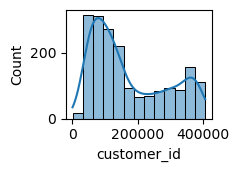

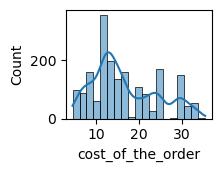

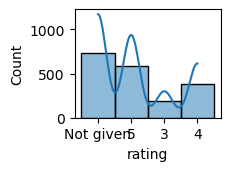

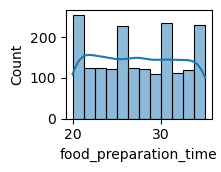

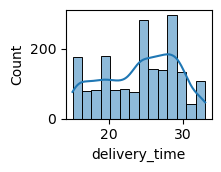

In [10]:
# Write the code here.
#Feel free to add more cells.

for col in columns_num:
     plt.subplot(3,3,1)
     sns.histplot(food_df1[col],kde = True)
    # plt.subplot(3,2,1)
    # plt.title('Visualizing {}'.format(col))
    # plt.hist(food_df1[col])
    # plt.xlabel('Occurrences')
    # plt.ylabel('Frequencies')
     plt.show()

    #working one for matplotlib
# for col in columns_num:
#     plt.subplot(3,2,1)
#     plt.title('Visualizing {}'.format(col))
#     plt.hist(food_df1[col])
#     plt.xlabel('Occurrences')
#     plt.ylabel('Frequencies')
#     plt.show()


In [13]:
food_df1.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


Having explored each feature of the dataset visually, my observation is that not all the features are normally distributed.
Data values for some columns seem to cluster about a certain range. Columns that seem to have outliers, their outliers seem grouped
Food_preparation_time seems to be the only feature that seems fairly normally distributed, suggesting that 

c:\Users\ekuba\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ekuba\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 142 (\x8e) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


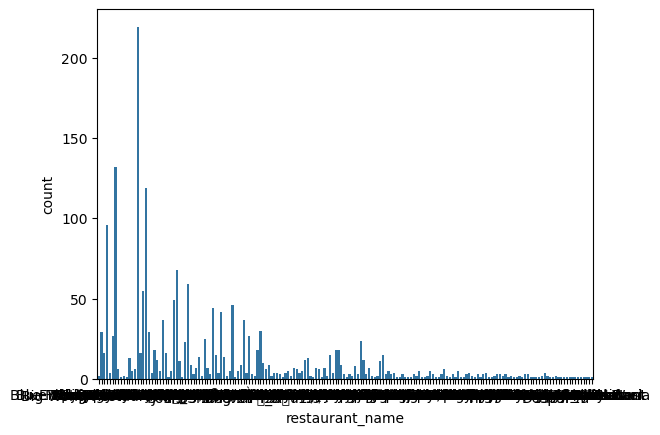

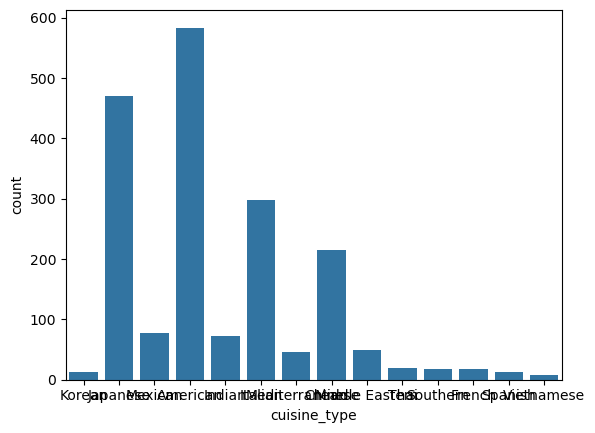

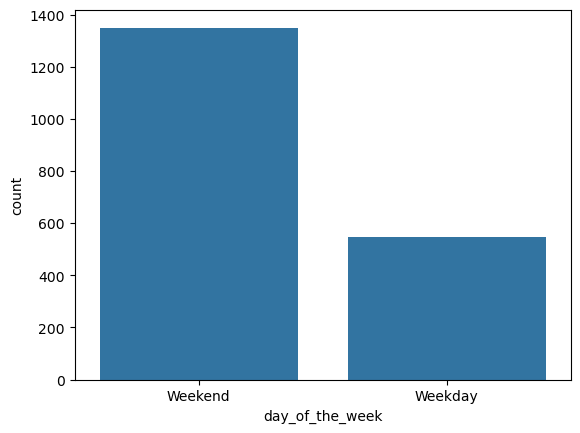

In [11]:

for col in columns_cat:
    sns.countplot(data =food_df1, x= food_df1[col])
    plt.show()

For the categorical features, I observe certain values of some feature occur more frequently than others. This shows that most od the categorical features are quite imbalanced and customers have more preferences for some kind of orders than others

### **Question 3**: Which are the top 5 restaurants in terms of the number of orders received?

In [ ]:
food_df1.head()

In [12]:
# Write the code here
# Feel free to add more cells
top_restaurants = food_df1.groupby('restaurant_name')['order_id'].count().sort_values(ascending=False)
top_restaurants.head()

#['order_id'].values_count()
#top_restaurants.get_group(('restaurant_name','order_id'))



restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: order_id, dtype: int64

The top 5 restaurants in terms of the number of orders received, ie. they have the highest number of orders are: Shake Shack, The meatball shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm  in descending order respectively

### **Question 4**: Which is the most popular cuisine on weekends?

In [13]:
weekend_most_pop = food_df1.groupby(['day_of_the_week','cuisine_type'])['cuisine_type'].count().sort_values(ascending=False)
weekend_most_pop

day_of_the_week  cuisine_type  
Weekend          American          415
                 Japanese          335
                 Italian           207
Weekday          American          169
Weekend          Chinese           163
Weekday          Japanese          135
                 Italian            91
Weekend          Mexican            53
Weekday          Chinese            52
Weekend          Indian             49
                 Middle Eastern     32
                 Mediterranean      32
Weekday          Mexican            24
                 Indian             24
                 Middle Eastern     17
Weekend          Thai               15
Weekday          Mediterranean      14
Weekend          French             13
                 Korean             11
                 Southern           11
                 Spanish            11
Weekday          Southern            6
                 French              5
                 Thai                4
Weekend          Vietnamese     

ORRRRRR

In [ ]:
# c = food_df1[food_df1['day_of_the_week']=='Weekend']
# c.head()

In [17]:
# Write the code here
# Feel free to add more cells

########
weekend_most_pop = food_df1[food_df1['day_of_the_week']=='Weekend'].groupby('cuisine_type').count()
weekend_most_pop.head()

,order_id,customer_id,restaurant_name,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
cuisine_type,,,,,,,,
American,415,415,415,415,415,415,415,415
Chinese,163,163,163,163,163,163,163,163
French,13,13,13,13,13,13,13,13
Indian,49,49,49,49,49,49,49,49
Italian,207,207,207,207,207,207,207,207


The most popular cuisine on weekends is American. It had the highest number of orders

### **Question 5**: What percentage of the orders cost more than 20 dollars?

In [14]:
# Write the code here
# Feel free to add more cells
#food_df1[['cost_of_the_order']]


orders_over_20 =(food_df1['cost_of_the_order']>= 20.0 ).sum()
orders_over_20



555

In [15]:
percentage_orders_over_20 = round((orders_over_20/1898)*100,2)
percentage_orders_over_20

29.24

There are 555 orders that cost more than 20 dollars. This accounts for about 29.24% app. 29%  of the total number of orders

### **Question 6**: What is the mean order delivery time?

In [16]:
# Write the code here
# Feel free to add more cells
avg_delivery_time = food_df1['delivery_time'].mean()
round(avg_delivery_time,2)

24.16

On average, it takes about 24 minutes for deliveries to be made to customers

### **Question 7:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [23]:
customers = food_df1.groupby('customer_id')['order_id'].count().sort_values(ascending=False).reset_index(name='numberof_orders')
#customers = food_df1.groupby('customer_id', as_index=False)['order_id'].count().sort_values(by= 'order_id', ascending=False)
customers.head(3)

,customer_id,numberof_orders
0,52832,13
1,47440,10
2,83287,9


The top 3 customers have the customer_id 52832, 47440 and 83287 frequenting the app to make orders 13,20 and 9 times respectively

In [ ]:
# Write the code here
# Feel free to add more cells
customers = food_df1[['customer_id']].nunique()
customers

This shows or measn they have 1200 customers in their dataset

## Bivariate/Multivariate Analysis

### **Question 8**: Perform a bivariate/multivariate analysis to explore relationships between the important variables in the dataset.


From this analysis the objective of foodhub  is to enhance their customer experience. What variables in this dataset are likely to enhance sutomer experience? I think it will be the cost, food preparation time and the delivery

<Axes: xlabel='rating', ylabel='delivery_time'>

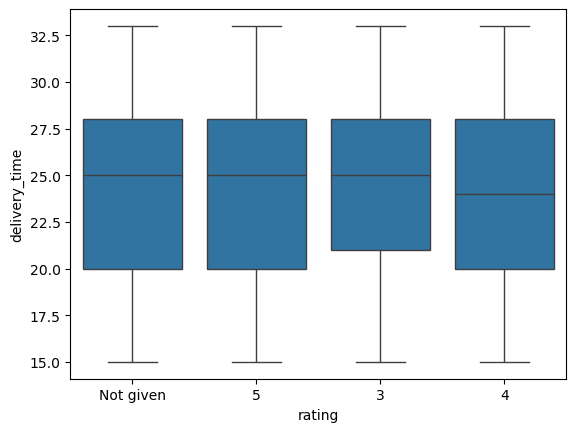

In [5]:
# Write the code here
# Feel free to add more cells
#plt.figure(figsize=(10,6))
sns.boxplot(data=food_df1, x= food_df1['rating'], y= food_df1['delivery_time'])

It seems delivery time seems qslightly consistent for all ratings given, we can conclude delivery time does not have much influence on the ratings customersgive

<Axes: xlabel='rating', ylabel='cost_of_the_order'>

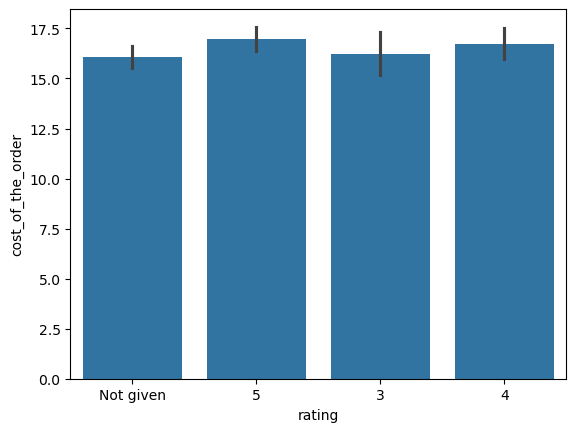

In [ ]:
sns.barplot(data=food_df1, x= food_df1['rating'], y= food_df1['cost_of_the_order'])

I can say that customers who aveargely spend more on their orders are those who are likely to give higher ratings. maybe the more expensive meals are more quality or more delicious or provide higher customer satisfaction

<Axes: xlabel='rating', ylabel='cost_of_the_order'>

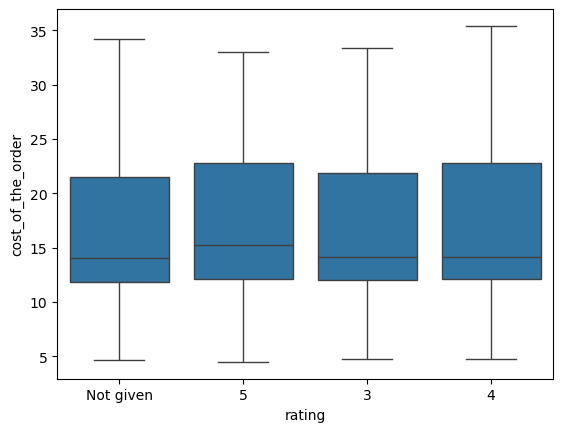

In [7]:
sns.boxplot(data=food_df1, x= food_df1['rating'], y= food_df1['cost_of_the_order'])

### **Question 9:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

i'm encoding not given ratings as 0

In [4]:
food_df1['rating'] = food_df1['rating'].replace('Not given',0)
food_df1['rating']=food_df1['rating'].astype(int)

In [5]:
advert_restataurants = food_df1.groupby('restaurant_name')['rating'].agg(['count','mean']).reset_index()
advert_restataurants.columns = ['restaurant_name', 'rating_count', 'avg_rate']
advert_restataurants.tail(40)

,restaurant_name,rating_count,avg_rate
138,Song Thai Restaurant & Bar,2,5.000000
139,Spice Thai,1,0.000000
140,Sushi Choshi,1,3.000000
141,Sushi Samba,11,3.545455
142,Sushi of Gari,16,2.062500
143,Sushi of Gari 46,37,1.945946
144,Sushi of Gari Tribeca,24,2.500000
145,TAO,49,2.489796
146,Tamarind TriBeCa,27,3.259259
147,Tarallucci e Vino Restaurant,2,0.000000


In [6]:
food_df1.head(40)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,0,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,0,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3,20,24
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,0,28,21
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30
8,1477174,121706,Anjappar Chettinad,Indian,16.44,Weekday,5,21,26
9,1477311,39705,Bukhara Grill,Indian,7.18,Weekday,5,29,26


In [ ]:
# consider_advert = food_df1.groupby('restaurant_name')['rating'].agg(['count','mean']).reset_index()
# consider_advert
# #advert_restataurants = food_df1['rating'].count() > 50 and food_df1['rating'].mean() > 4


# #advert_restataurants = food_df1.groupby('restaurant_name')['rating'].count().reset_index(name = 'rate_count')
# #advert_restataurants

In [ ]:
# # Write the code here
# # Feel free to add more cells
# advert_restataurants = food_df1.groupby('restaurant_name')['rating'].count().reset_index(name = 'rate_count')
# #advert_restataurants = food_df1.groupby('restaurant_name')['rating'].count().reset_index(name = 'rate_count')
# advert_restataurants


# #advert_restataurants.sum()

In [7]:
#promo_restaurants_a = advert_restataurants[advert_restataurants['rating_count']>50 ]
promo_restaurants_a = advert_restataurants[(advert_restataurants['rating_count']>50) & (advert_restataurants['avg_rate'] > 4)]
promo_restaurants_a


,restaurant_name,rating_count,avg_rate


In [31]:
promo_restaurants_final = promo_restaurants_a[promo_restaurants_a['avg_rate']>4]
promo_restaurants_final

,restaurant_name,rating_count,avg_rate


It looks like restaurants who have higher counts of being rated do not have rates greater than 4. So they cannot gieve out their discount unless they revise their conditions for offering discount. **Unless I didn't do somthing well**


### **Question 10:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

This question is a bit ambiguous. Does 15% charge apply to orders greater than 5 dollars but less than 20 dollars or it applies explicitly as stated in the question? If so wouldn't that be a double charge of some sort?
**I will assume 15% charge is on orders greater than 5 dollars but less than 20**

In [8]:
orders_above_5 = food_df1[(food_df1['cost_of_the_order'] > 5.00 )& (food_df1['cost_of_the_order']< 20.00)].copy()
orders_above_5

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,0,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,0,28,21
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30
...,...,...,...,...,...,...,...,...,...
1890,1477316,164776,TAO,Japanese,15.67,Weekend,5,20,22
1891,1476981,138586,Shake Shack,American,5.82,Weekend,0,22,28
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


In [9]:
orders_above_5['service_charge'] = orders_above_5['cost_of_the_order']*0.15
revenue_b = orders_above_5['service_charge'].sum()
print(f'Revenue on orders above 5 dollars but less than 20 dollars is ${revenue_b:.2f}')

Revenue on orders above 5 dollars but less than 20 dollars is $2477.58


In [6]:
# Write the code here
# Feel free to add more cells
# orders_above_20 = food_df1['cost_of_the_order']> 20.0
# charge_less_than_20 = orders_above_20 * 0.25
# charge_less_than_20

orders_above_20 = food_df1[food_df1['cost_of_the_order']> 20.0].copy()
orders_above_20
#food_df1[food_df1['cost_of_the_order']> 5.0]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3,20,24
12,1476966,129969,Blue Ribbon Fried Chicken,American,24.30,Weekend,5,23,17
17,1477373,139885,Blue Ribbon Sushi Izakaya,Japanese,33.03,Weekend,Not given,21,22
...,...,...,...,...,...,...,...,...,...
1884,1477437,304993,Shake Shack,American,31.43,Weekend,3,31,24
1885,1477550,97324,Shake Shack,American,29.05,Weekday,4,27,29
1892,1477473,97838,Han Dynasty,Chinese,29.15,Weekend,Not given,29,21
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17


In [7]:
orders_above_20['service_charge']= orders_above_20['cost_of_the_order'] * 0.25
revenue_a = orders_above_20['service_charge'].sum()
print(f'Revenue on orders above 20 dollars is ${revenue_a:.2f}') 
#charge_less_than_20 = orders_above_20[orders_above_20['cost_of_the_order'] * 0.25]
#charge_less_than_20

Revenue on orders above 20 dollars is $3688.73


In [33]:
print(f'Net revenue generated across all orders is ${revenue_a + revenue_b:.2f}')

Net revenue generated across all orders is $6166.30


### *The company generates total revenue worth $6166.30 across all orders* To determine if they are profitin or not, they would need to provide the costs incures

### **Question 11:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [8]:
# Write the code here
# Feel free to add more cells
food_df1.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [24]:
food_time = food_df1[['order_id','customer_id','restaurant_name','cuisine_type','cost_of_the_order', 'day_of_the_week','rating','food_preparation_time', 'delivery_time']].copy()
food_time['total_prep_del_time'] = food_time['food_preparation_time'] + food_time['delivery_time']
orders_over_60min = food_time[food_time['total_prep_del_time'] > 60].shape[0]
prct_orders_over_60min = (orders_over_60min/1898)*100
print(f'{prct_orders_over_60min:.2f}% of orders take  over 60 minutes to be delivered')

#food_time['total_prep_del_time'].count()
#food_df1['total_prep_del_time'] = food_df1[food_df1['food_preparation_time'] + food_df1['delivery_time'] > 60]

10.54% of orders take  over 60 minutes to be delivered


About 1/10th of their orders take more than an hour to get ready. This seems quite okay. However, this percentage could be reduced, especially concerning cuisines that are highly patronized by customers.

### **Question 12:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [25]:
food_df1.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [31]:
food_df1[food_df1['day_of_the_week']=='Weekend'].groupby('day_of_the_week')['delivery_time'].mean()

day_of_the_week
Weekend    22.470022
Name: delivery_time, dtype: float64

In [32]:
food_df1[food_df1['day_of_the_week']=='Weekday'].groupby('day_of_the_week')['delivery_time'].mean()

day_of_the_week
Weekday    28.340037
Name: delivery_time, dtype: float64

It takes about 22 minutes on average during the weekends to deliver food but it takes about 28 minutes on average to deliver foods during the weekday.  From the earlier visual analyis, demand during the weekday is low while demand during the weekend is high. You would think with this it should be the other way round in terms of the average delivery times.However, It could be that more delivery people are stationed over the weekend to help with faster delivery of orders since it takes a shorter time to deliver. If this is an intentional strategy by FoodHub, then they're doing well with it.


## Conclusion and Recommendations

### **Question 13:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)

### Conclusions:
*  


### Recommendations:

*  Foodhub should investigate and identify what accounts for  slower delivery time on weekdays even though there are lower orders during the weekdays in their operations. The findings should help influence creating an ETA on the UI that can help manage customers expectation of arrival
* They should also investigate and identify the cause of lower orders on the weekdays and having identified that,  determine what strategies could help boost orders during the weekdays
* Since a lot of the orders were unrated, they could consider simplifying existing rating procedure so users don't deem it requiring extra effort to rate. They could further go on to provide incentives to encourage users who rate after simplifying the UX
* Since American cuisine is the most popular cuisine on weekends and even weekdays, Foodhub can run promos on this cuisine type across all restaurants that serve it to further boost sales for a period of time. However, they can also run promos for a longer period of time to boost sales of the cuisines that don't receive higher orders



---